<a href="https://colab.research.google.com/github/SreeLekha-27/Main-Project-/blob/main/Air_Quality_Main_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Monitoring and Forecasting Air Pollution Levels**

# Environmental Analytics

# **Problem Definition and Dataset Selection**

# **Objective**

1. Air pollution is a growing environmental and public health concern across urban and industrial regions.

2. The project aims to clean, analyze, and visualize air quality data to identify pollution trends and patterns.

3. Extracting meaningful insights from the dataset can help support environmental monitoring and decision-making.

4. The project aims to provide data-driven recommendations for improving environmental awareness and sustainability.



# **Outcome**

1. The project aims to identify key patterns and trends in air quality data across different time periods and geographic locations.

2. EDA will be used to examine variations in pollutant levels and detect periods of high pollution concentration.

3. Data cleaning and preprocessing improved the accuracy and reliability of the dataset before detailed analysis.

4. Visualizations such as line charts, bar charts, box plots, and heatmaps will be created to clearly illustrate pollution trends, seasonal patterns, and relationships between pollutants.

5. The overall analysis is expected to provide meaningful insights into air pollution behavior, supporting data-driven environmental monitoring and informed decision-making

#**Dataset Information**

**Source:** Government Open Data Portal (Data.gov - U.S. Environmental Protection Agency) **[Dataset](https://catalog.data.gov/dataset/air-quality)**

**Year / Timeline:** Data collected from 2000 to 2024

**Dataset Column/features Description:**

* Unique ID - A unique identifier for each record in the dataset.

* Indicator ID - Code that represents the type of air quality indicator (e.g., PM2.5, NO2).

* Name - The name of the air quality indicator or pollutant.

* Measure - The unit or type of measurement (e.g., annual average concentration).

* Measure Info - Additional information about how the measurement is calculated.

* Geo Type Name - The geographic level of the data (e.g., city, county, neighborhood).

* Geo Join ID - Geographic code used to join this dataset with other location datasets.

* Geo Place Name - Name of the location (e.g., New York, Manhattan).

* Time Period - The time range or year for which the data was recorded.

* Start_Date - The starting date of the data collection period.

* Data Value - The actual air quality measurement value (pollution level).

* Message - Additional notes or warnings related to the data (if any).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("https://raw.githubusercontent.com/SreeLekha-27/Main-Project-/refs/heads/main/Air_Quality.csv")
df.head()

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message
0,336867,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Winter 2014-15,12/01/2014,23.97,NaN
1,336741,375,Nitrogen dioxide (NO2),Mean,ppb,CD,107,Upper West Side (CD7),Winter 2014-15,12/01/2014,27.42,NaN
2,550157,375,Nitrogen dioxide (NO2),Mean,ppb,CD,414,Rockaway and Broad Channel (CD14),Annual Average 2017,01/01/2017,12.55,NaN
3,412802,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Winter 2015-16,12/01/2015,22.63,NaN
4,412803,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Summer 2016,06/01/2016,14.00,NaN


In [3]:
df.shape

(18862, 12)

In [4]:
df.columns

Index(['Unique ID', 'Indicator ID', 'Name', 'Measure', 'Measure Info',
       'Geo Type Name', 'Geo Join ID', 'Geo Place Name', 'Time Period',
       'Start_Date', 'Data Value', 'Message'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18862 entries, 0 to 18861
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unique ID       18862 non-null  int64  
 1   Indicator ID    18862 non-null  int64  
 2   Name            18862 non-null  object 
 3   Measure         18862 non-null  object 
 4   Measure Info    18862 non-null  object 
 5   Geo Type Name   18862 non-null  object 
 6   Geo Join ID     18862 non-null  int64  
 7   Geo Place Name  18862 non-null  object 
 8   Time Period     18862 non-null  object 
 9   Start_Date      18862 non-null  object 
 10  Data Value      18862 non-null  float64
 11  Message         0 non-null      float64
dtypes: float64(2), int64(3), object(7)
memory usage: 1.7+ MB


In [6]:
df['Start_Date'] = pd.to_datetime(df['Start_Date'])

In [7]:
df.describe()

,Unique ID,Indicator ID,Geo Join ID,Start_Date,Data Value,Message
count,18862.000000,18862.000000,1.886200e+04,18862,18862.000000,0.0
mean,452004.167533,431.817888,5.983262e+05,2015-03-01 00:12:40.385961216,21.051580,NaN
min,130355.000000,365.000000,1.000000e+00,2005-01-01 00:00:00,0.000000,NaN
25%,176073.250000,365.000000,2.020000e+02,2011-06-01 00:00:00,8.742004,NaN
50%,412490.500000,375.000000,3.030000e+02,2015-01-01 00:00:00,14.790000,NaN
75%,669588.750000,386.000000,4.040000e+02,2019-01-01 00:00:00,26.267500,NaN
max,878254.000000,661.000000,1.051061e+08,2023-06-01 00:00:00,424.700000,NaN
std,262910.731230,113.946565,7.819721e+06,NaN,23.564920,NaN


In [8]:
df.isnull().sum()

,0
Unique ID,0
Indicator ID,0
Name,0
Measure,0
Measure Info,0
Geo Type Name,0
Geo Join ID,0
Geo Place Name,0
Time Period,0
Start_Date,0


In [9]:
df.duplicated().sum()

np.int64(0)

# **Data Cleaning and Pre-processing**

In [10]:
df.drop('Message', axis=1, inplace=True)

In [11]:
df.isnull().sum()

,0
Unique ID,0
Indicator ID,0
Name,0
Measure,0
Measure Info,0
Geo Type Name,0
Geo Join ID,0
Geo Place Name,0
Time Period,0
Start_Date,0


In [12]:
df.rename(columns={'Name': 'Indicator_Name','Geo Place Name': 'Loction'},inplace=True)

In [13]:
df.columns=df.columns.str.replace(" ", "_")

In [14]:
df.drop(['Unique_ID', 'Geo_Join_ID'], axis=1, inplace=True)

In [15]:
df.columns

Index(['Indicator_ID', 'Indicator_Name', 'Measure', 'Measure_Info',
       'Geo_Type_Name', 'Loction', 'Time_Period', 'Start_Date', 'Data_Value'],
      dtype='object')

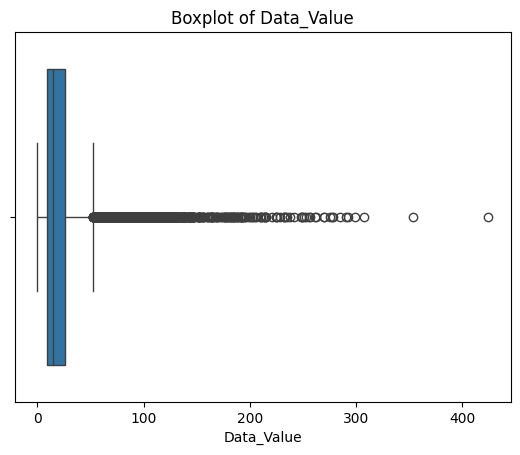

In [16]:
# BOx Plot
sns.boxplot(x=df['Data_Value'])
plt.title("Boxplot of Data_Value")
plt.show()

# **Insight**
The boxplot reveals the presence of extreme values in the Data_Value column. However, these high pollution levels are likely real environmental events rather than data errors. Therefore, the outliers were retained to preserve meaningful environmental information.

In [17]:
df['Data_Value'].skew()

np.float64(4.826817828955299)

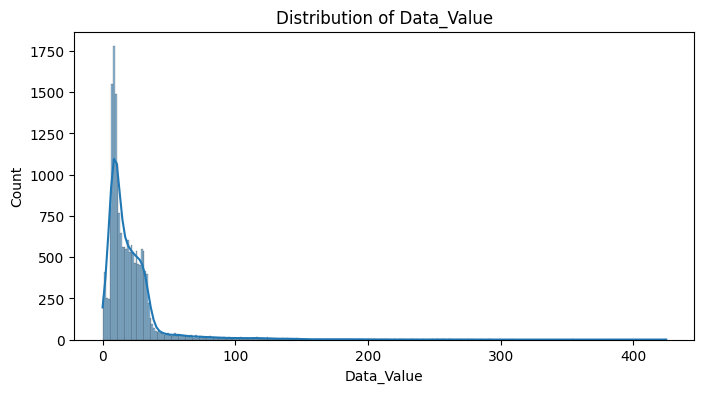

In [18]:
plt.figure(figsize=(8,4))
sns.histplot(df['Data_Value'], kde=True)
plt.title("Distribution of Data_Value")
plt.show()

In [19]:
df['Data_Value_Log'] = np.log1p(df['Data_Value'])

In [20]:
df['Data_Value_Log'].skew()

np.float64(0.012789799377283992)

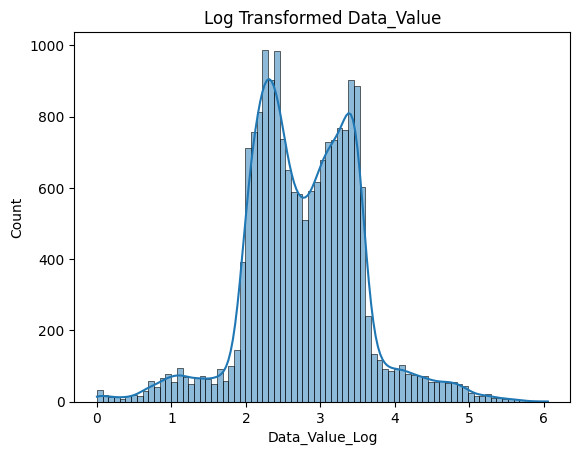

In [21]:
sns.histplot(df['Data_Value_Log'], kde=True)
plt.title("Log Transformed Data_Value")
plt.show()

# **Insight**

The original Data_Value column showed extreme positive skewness (4.82), indicating the presence of high pollution spikes. Since these spikes represent real environmental events, they were retained. So I applied log transformation to reduce skewness. After transformation, skewness reduced to approximately 0.48, resulting in a near-normal distribution suitable for advanced statistical analysis and modeling.

In [22]:
df['Year'] = df['Start_Date'].dt.year

In [23]:
df['Month'] = df['Start_Date'].dt.month

In [24]:
df['Quarter'] = df['Start_Date'].dt.quarter

In [25]:
def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Summer'
    elif month in [6,7,8,9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

df['Season'] = df['Month'].apply(get_season)

In [26]:
df.head()

,Indicator_ID,Indicator_Name,Measure,Measure_Info,Geo_Type_Name,Loction,Time_Period,Start_Date,Data_Value,Data_Value_Log,Year,Month,Quarter,Season
0,375,Nitrogen dioxide (NO2),Mean,ppb,CD,Flushing and Whitestone (CD7),Winter 2014-15,2014-12-01,23.97,3.217675,2014,12,4,Winter
1,375,Nitrogen dioxide (NO2),Mean,ppb,CD,Upper West Side (CD7),Winter 2014-15,2014-12-01,27.42,3.347093,2014,12,4,Winter
2,375,Nitrogen dioxide (NO2),Mean,ppb,CD,Rockaway and Broad Channel (CD14),Annual Average 2017,2017-01-01,12.55,2.606387,2017,1,1,Winter
3,375,Nitrogen dioxide (NO2),Mean,ppb,CD,Flushing and Whitestone (CD7),Winter 2015-16,2015-12-01,22.63,3.162517,2015,12,4,Winter
4,375,Nitrogen dioxide (NO2),Mean,ppb,CD,Flushing and Whitestone (CD7),Summer 2016,2016-06-01,14.00,2.708050,2016,6,2,Monsoon


# **Insight**
So, I extracted the Year, Month, Quarter, and Season from the Start_Date column to enable temporal analysis. These features help in identifying long-term trends, seasonal variations, and periodic patterns in pollution levels.

# **EDA and Visualizations**

# Histogram – Pollution Distribution

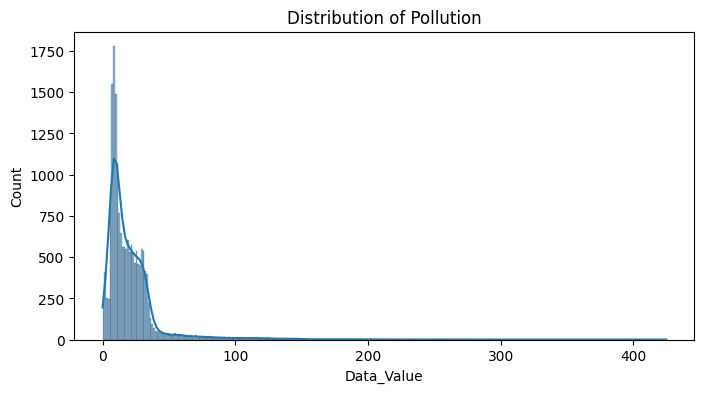

In [27]:
plt.figure(figsize=(8,4))
sns.histplot(df['Data_Value'],kde=True)
plt.title("Distribution of Pollution")
plt.show()

# **Insight**

* Pollution values are positively skewed.

* Majority of observations lie in the lower pollution range.

* Few extreme high pollution readings create a long right tail.

* Distribution is not normal.

# **Interpretation**

This histogram shows the frequency distribution of pollution values.

Most pollution readings are concentrated in the lower range, indicating that pollution is generally moderate. However, there are few extreme high values which create a right-skewed distribution.

Features used: **Data_Value**

Presence of skewness, Existence of extreme pollution events.

# Countplot – Records by Season

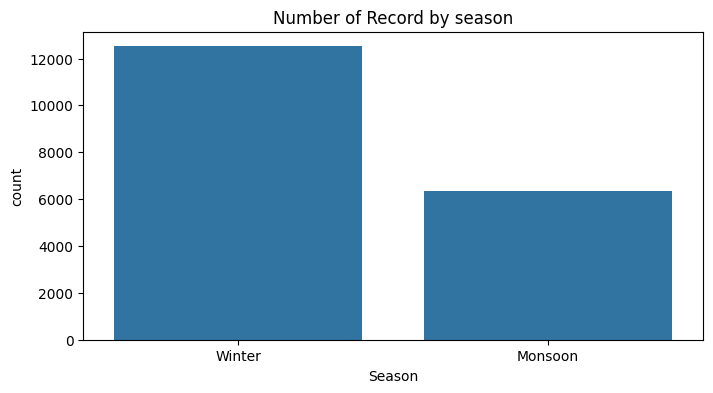

In [28]:
plt.figure(figsize=(8,4))
sns.countplot(x='Season',data=df)
plt.title("Number of Record by season")
plt.show()

# **Insight**

* Winter season has the highest number of recorded pollution observations.

* Monsoon has comparatively fewer records.

* Data collection is not evenly distributed across seasons.

# **Interpretation**

This countplot shows the number of pollution records available for each season.

Winter has more recorded data compared to Monsoon. This indicates that data collection may be more focused during winter, possibly because pollution levels are expected to be higher during this period.

Features used: **Season**

Authorities may prioritize monitoring during winter due to historically higher pollution risks.

#  Line Plot – Pollution Trend Over Years

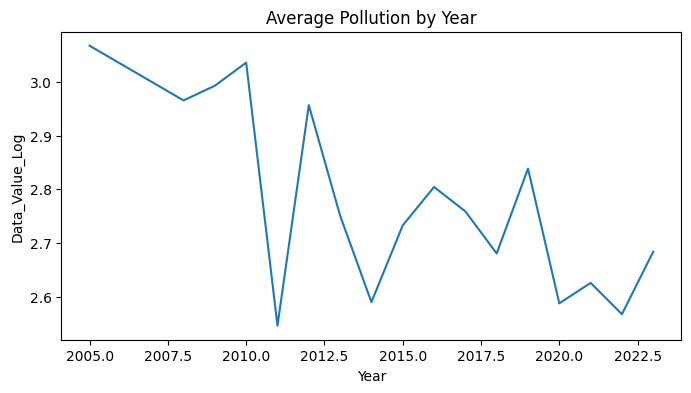

In [37]:
year_avg = df.groupby('Year')['Data_Value_Log'].mean().reset_index()

plt.figure(figsize=(8,4))
sns.lineplot(x='Year', y='Data_Value_Log', data=year_avg)
plt.title("Average Pollution by Year")
plt.show()

# **Insights**

* Pollution shows fluctuations across years.

* Higher pollution levels are observed in the early years (2005–2010).

* After 2011, the values generally remain lower, suggesting a gradual reduction.

* No consistent long-term increase in pollution is observed.
# **Interpretation**

The chart indicates that average pollution levels vary across years but show a slight overall decline over time. The higher values in the early years followed by relatively lower values in later years suggest that pollution levels may be gradually improving or stabilizing, possibly due to environmental regulations or improved emission controls.

Features used: **Year, Data_Value**

Helps evaluate long-term effectiveness of environmental policies

# Barplot – Average Pollution by Season

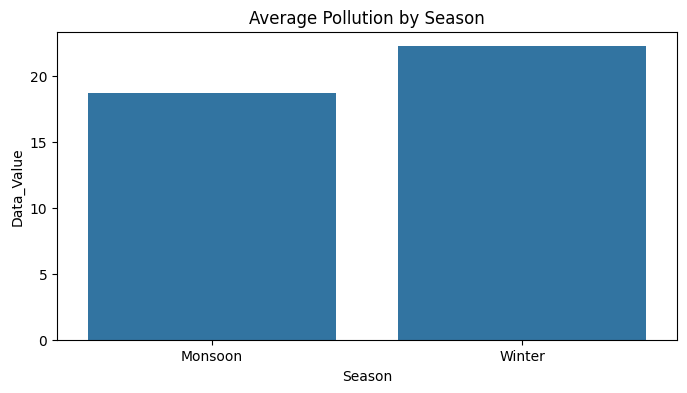

In [39]:
season_avg = df.groupby('Season')['Data_Value'].mean().reset_index()

plt.figure(figsize=(8,4))
sns.barplot(x='Season', y='Data_Value', data=season_avg)
plt.title("Average Pollution by Season")
plt.show()

# **Insight**

* Pollution levels vary across seasons.

* Winter shows higher average pollution.

* Monsoon show comparatively lower values.

* Seasonal variation clearly impacts pollution levels.

* Pollution is not uniformly distributed throughout the year.

# **Interpretation**

The chart shows that pollution levels differ depending on the season.
Certain seasons experience higher pollution, while others show relatively lower pollution levels.

Features I Used: **Season, Data_Value, Used groupby**

Seasonal factors significantly influence pollution.
High-pollution seasons require stronger monitoring, stricter regulations, and preventive measures.

# Pollution by Location

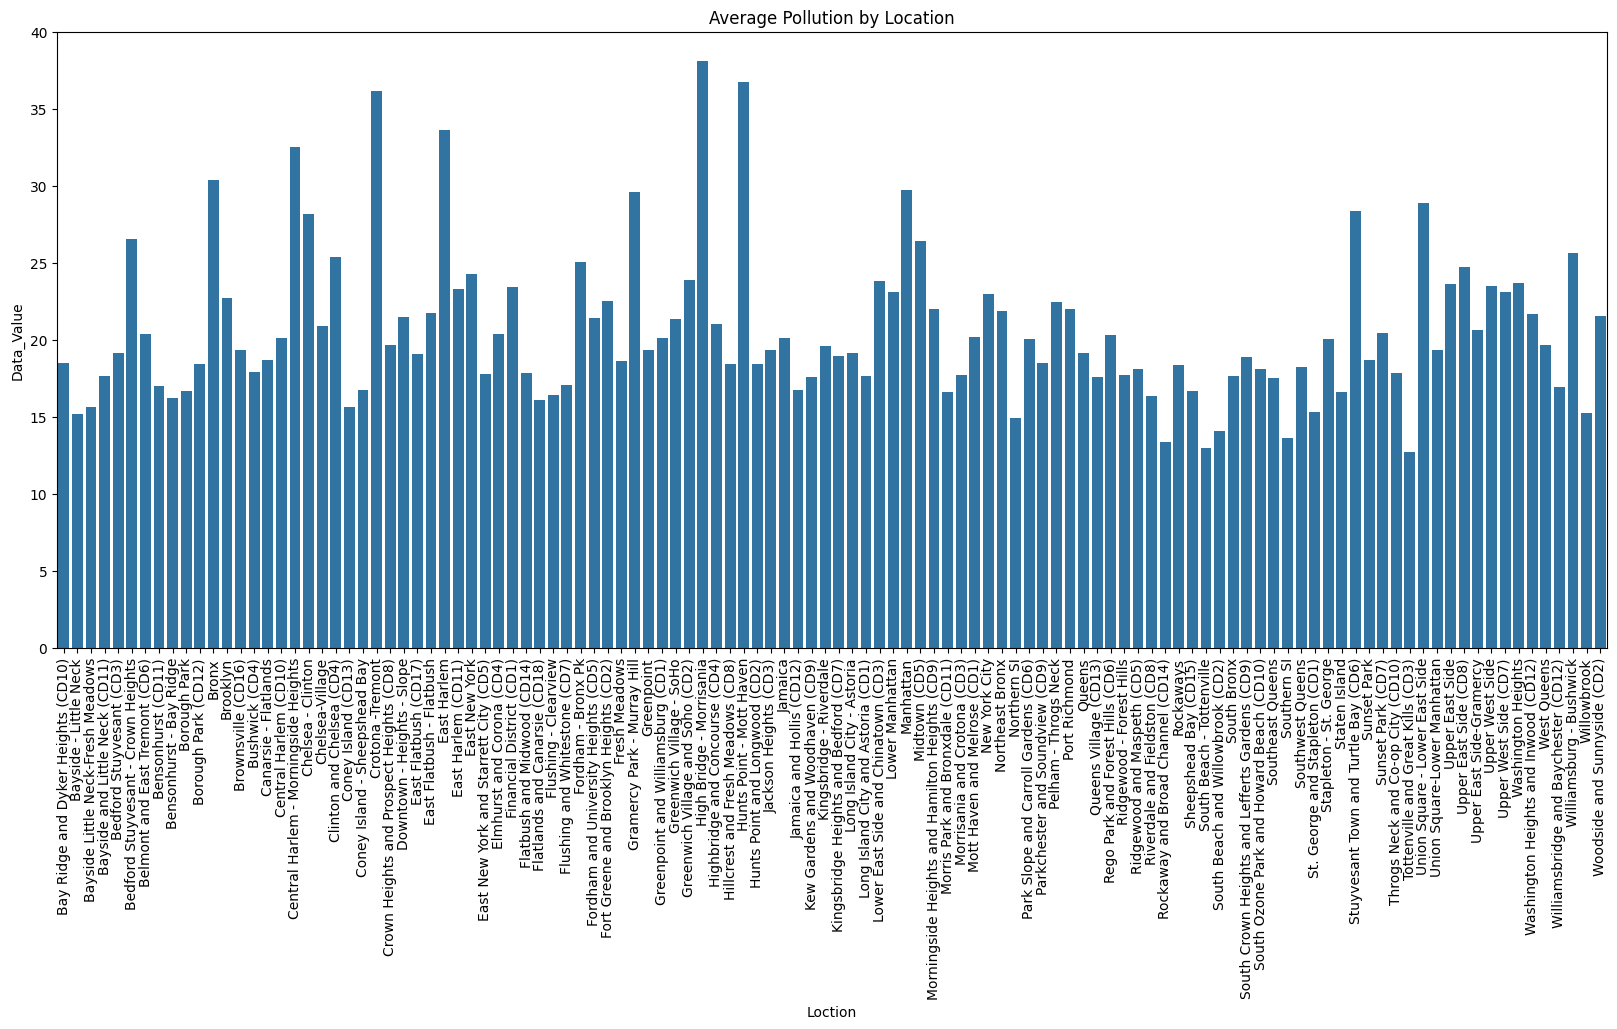

In [31]:
location_avg = df.groupby('Loction')['Data_Value'].mean().reset_index()

plt.figure(figsize=(20,8))
sns.barplot(x='Loction', y='Data_Value', data=location_avg)
plt.xticks(rotation=90)
plt.title("Average Pollution by Location")
plt.show()

# **Insight**

* Pollution levels vary significantly across different locations.

* Some locations have noticeably higher average pollution compared to others.

* A few areas show moderate pollution levels, forming the majority of the dataset.

* Only a small number of locations appear to have relatively low average pollution.

* Pollution distribution is uneven, indicating location-based environmental differences.

# **Interpretation**

This suggests that pollution is not uniformly distributed. Certain locations are more affected, possibly due to industrial activity, traffic congestion, population density, or other environmental factors.

Features I Used: **Location, Pollution value**

Mean (average) pollution per location

A comparison of pollution levels across locations.

Identification of high-pollution and low-pollution areas.

# Correlation Heatmap

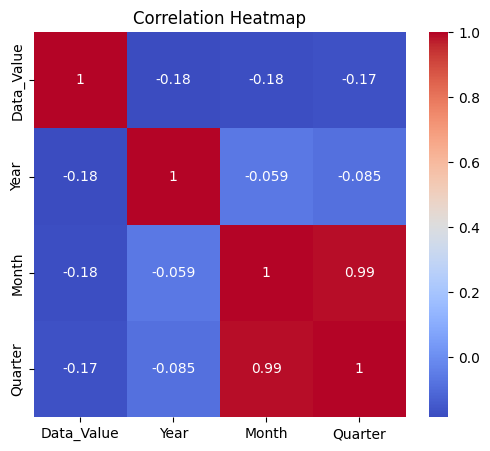

In [32]:
plt.figure(figsize=(6,5))
sns.heatmap(df[['Data_Value','Year','Month','Quarter']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# **Insights**

Weak correlation between time and pollution.

Month and Quarter strongly correlated.

# **Interpretation**

The heatmap shows weak negative correlation between pollution and time-related variables.

Features used: **Data_Value**, **Year**, **Month**, **Quarter**

This means pollution does not have a strong linear increase over time.

Month and Quarter are highly correlated because Quarter is derived from Month.

# Year + Season Trend

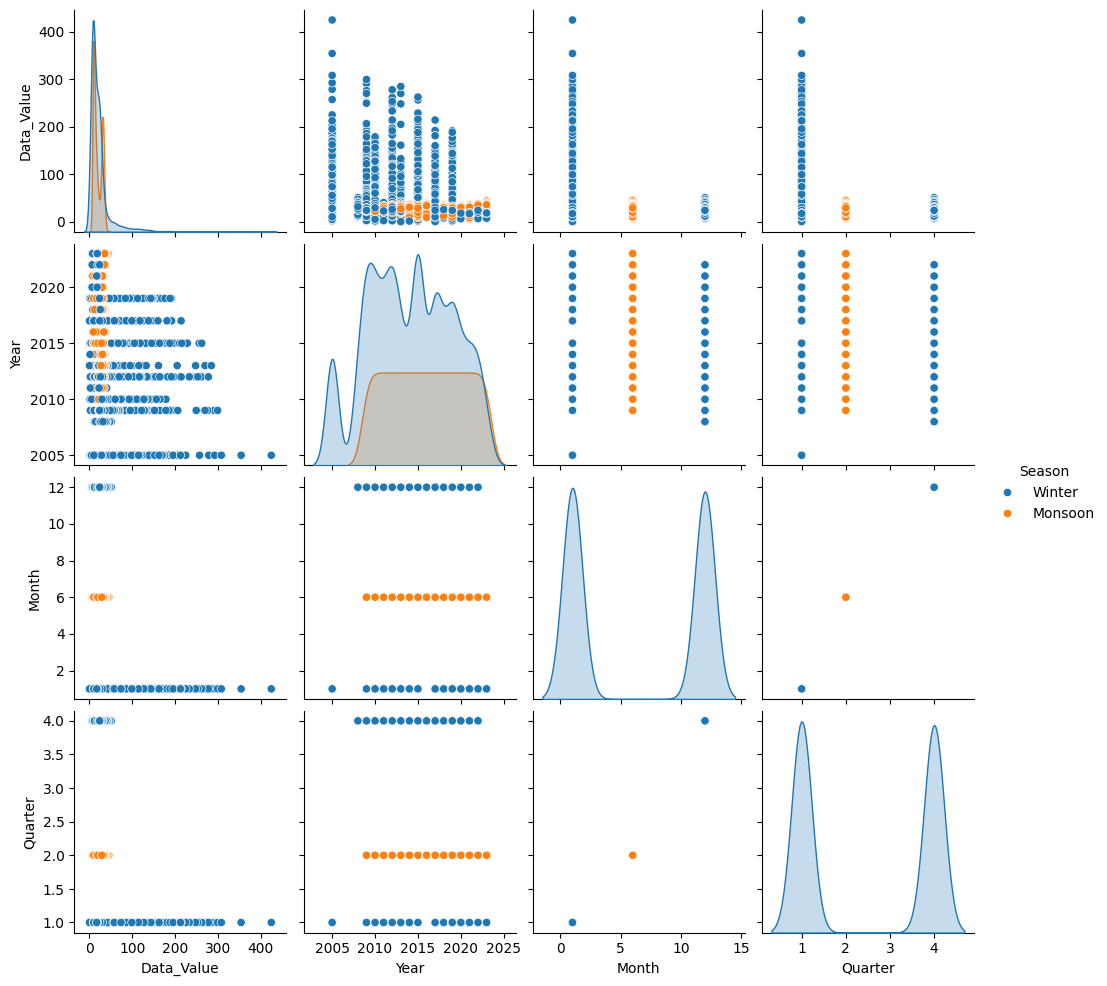

In [33]:
sns.pairplot(df[['Data_Value','Year','Month','Quarter','Season']],
             hue='Season',
             diag_kind='kde')
plt.show()

# **Insight**
* Pollution distribution is positively skewed, indicating most values are low with a few extreme spikes.

* There is no strong linear relationship between Year and Data_Value.

* Month and Quarter show a strong relationship because Quarter is derived from Month.

* Seasonal patterns are visible, but the clusters overlap significantly.

* Pollution levels vary slightly across seasons, with winter showing slightly higher values.

* No consistent increasing or decreasing trend over time is observed.
# **Interpretation**

This pairplot visualizes the relationships among multiple numerical variables while grouping them by Season.

Variables used: **Data_Value, Year, Month, Quarter, Season**

* Pollution does not show a clear long-term increasing trend.

* Seasonal effects exist but do not create completely separate pollution patterns.

* Month and Quarter exhibit a strong structural relationship due to feature derivation.

* Pollution levels overlap across seasons, indicating multiple environmental factors influence pollution levels.

# Pollution by Indicator Type

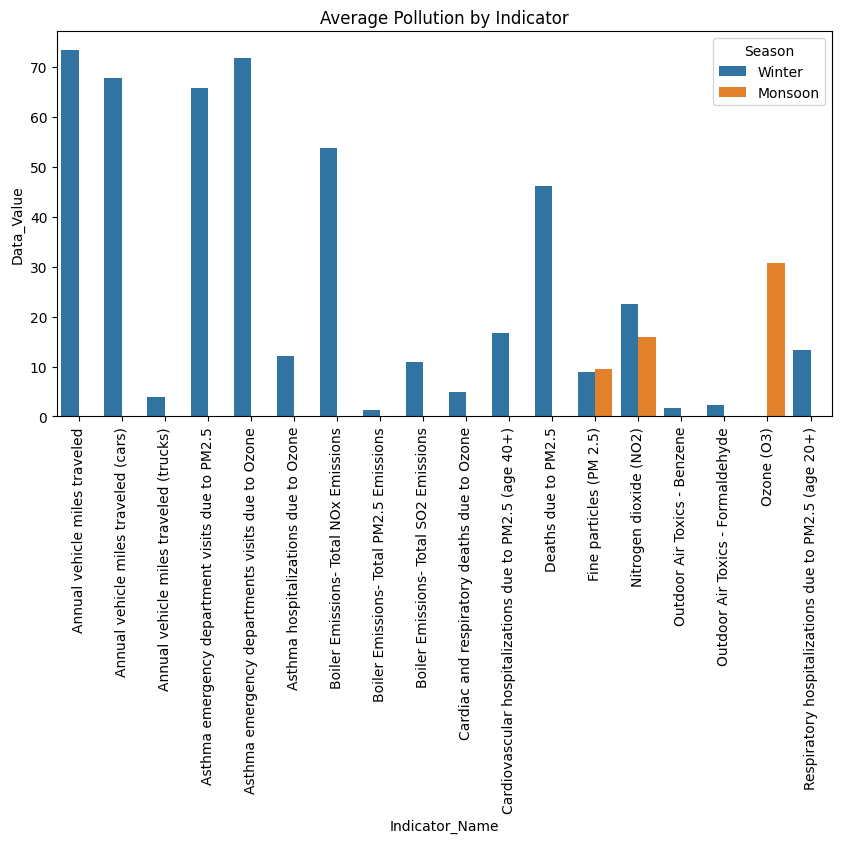

In [34]:
grouped_indicator = df.groupby(['Indicator_Name','Season'])['Data_Value'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(x='Indicator_Name', y='Data_Value', hue='Season', data=grouped_indicator)
plt.xticks(rotation=90)
plt.title("Average Pollution by Indicator")
plt.show()

# **Insight**

* Pollution levels vary across different pollutant types.

* Certain indicators show consistently higher average pollution values.

* Seasonal variation is visible within each pollutant type.

* Some pollutants increase significantly in specific seasons.

* Pollution behavior is not uniform across indicators or seasons.

# **Interpretation**

The chart shows that pollution levels differ not only by pollutant type but also by season.

Some pollutants show higher concentration in specific seasons, indicating seasonal sensitivity.

This suggests that pollution patterns are influenced by both the type of pollutant and environmental conditions.

**Indicator_Name, Season, Data_Value**

# Pivot Table Heatmap (Year vs Season)

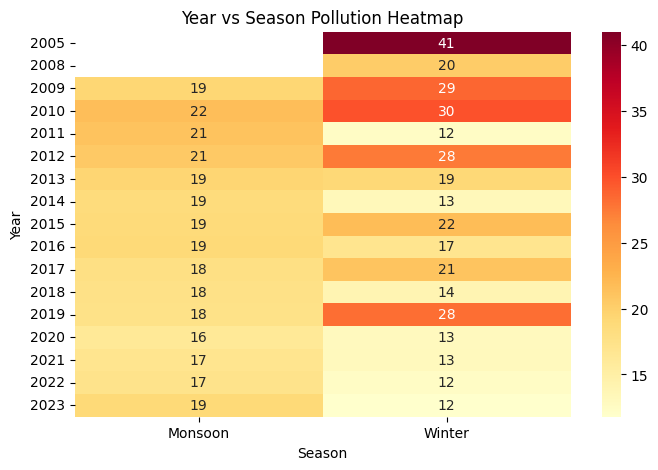

In [35]:
pivot_multi = df.pivot_table(values='Data_Value',
                             index='Year',
                             columns='Season',
                             aggfunc='mean')

plt.figure(figsize=(8,5))
sns.heatmap(pivot_multi, annot=True, cmap='YlOrRd')
plt.title("Year vs Season Pollution Heatmap")
plt.show()

# **Insight**

* Winter consistently has darker shades → higher pollution.

* Monsoon seasons show lighter shades → lower pollution.

* Some years show extreme pollution peaks in Winter.

* Seasonal variation is consistent across most years.

* The heatmap clearly highlights high-risk year-season combinations.

# **Interpretation**

Pollution shows a strong seasonal pattern, with Winter being the most polluted season.

Monsoon season consistently records lower pollution, likely due to rainfall reducing airborne pollutants.

Over time, especially in recent years (2020–2023), pollution levels appear to be gradually decreasing, particularly in Winter.

The extreme spike in 2005 suggests either a major pollution event or limited regulation during that period.

Overall, this heatmap demonstrates that Season + Year together significantly influence pollution levels, with Winter being the critical high-risk period across most years.

# **Presentation**

In [36]:
df.to_csv("Air_Quality_Final.csv", index=False)

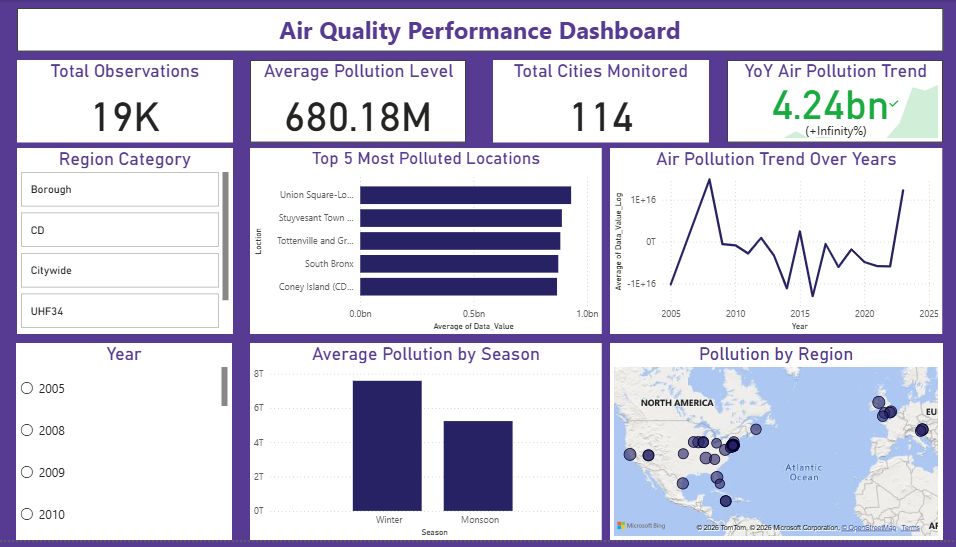

# **Insights**
1. Major Seasonal Shift Around 2019–2020
  
    The seasonal pollution graph shows variations across different seasons. Pollution levels appear to fluctuate over the years, with noticeable changes around 2019–2020.

2. Regional Pollution Concentration

    The map visualization indicates that pollution levels vary by region. Certain areas show higher pollution intensity compared to others, suggesting localized environmental factors.

3. Dominant Pollutant Categories

    The pollutant category chart highlights which pollutants contribute most to overall pollution levels, helping identify key pollutants that require monitoring and control.

4. Pollution Trend Over Time

    The yearly trend chart shows fluctuations in pollution levels across different years. While some years show decreases, the overall trend suggests gradual variation rather than a consistent increase or decrease.

# **Conclusion**
**For Government**

* Investigate the 2019–2020 spike to identify root causes.

* Strengthen urban emission regulations in the most polluted locations.

* Implement seasonal pollution control plans, especially before winter.

* Increase monitoring in rapidly growing cities.

**For Businesses**

Companies in high-pollution areas should:

* Invest in cleaner technologies

* Improve emission controls

* Prepare for potential stricter regulations

**For Urban Planning Authorities**

* Promote public transport and EV adoption

* Increase green zones and tree coverage

* Introduce traffic management during peak pollution seasons

The analysis of air quality data reveals that pollution levels vary across time, regions, and seasons. While some improvements may be observed in certain years, fluctuations remain present. Monitoring dominant pollutants and regional pollution patterns can help policymakers design more effective environmental strategies to improve air quality.